# Dealing with Categorical Variables - Lab

## Introduction

In this lab, you'll explore the Ames Housing dataset and identify numeric and categorical variables. Then you'll transform some categorical data and use it in a multiple regression model.

## Objectives

You will be able to:

* Determine whether variables are categorical or numeric
* Use one-hot encoding to create dummy variables

## Step 1: Load the Ames Housing Dataset

Import `pandas`, and use it to load the file `ames.csv` into a dataframe called `ames`. If you pass in the argument `index_col=0` this will set the "Id" feature as the index.

In [5]:
# Your code here - load the dataset

# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Loading the dataset
ames = pd.read_csv('ames.csv', index_col=0)

Visually inspect `ames` (it's ok if you can't see all of the columns).

In [7]:
# Your code here

# inspecting the dataset
print(ames.head())
print(ames.info())  # Checking the data types and missing values

    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   
4           70       RL         60.0     9550   Pave   NaN      IR1   
5           60       RL         84.0    14260   Pave   NaN      IR1   

   LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
Id                                  ...                                     
1          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
2          Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
3          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
4          Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
5          Lvl    AllPub       FR2  ... 

Go ahead and drop all **columns** with missing data, to simplify the problem. Remember that you can use the `dropna` method ([documentation here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)).

In [9]:
# Your code here - drop columns with missing data

# Dropping columns with missing data
ames_clean = ames.dropna(axis=1)

# Confirming columns with missing data are dropped
print(ames_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1460 non-null   int64 
 1   MSZoning       1460 non-null   object
 2   LotArea        1460 non-null   int64 
 3   Street         1460 non-null   object
 4   LotShape       1460 non-null   object
 5   LandContour    1460 non-null   object
 6   Utilities      1460 non-null   object
 7   LotConfig      1460 non-null   object
 8   LandSlope      1460 non-null   object
 9   Neighborhood   1460 non-null   object
 10  Condition1     1460 non-null   object
 11  Condition2     1460 non-null   object
 12  BldgType       1460 non-null   object
 13  HouseStyle     1460 non-null   object
 14  OverallQual    1460 non-null   int64 
 15  OverallCond    1460 non-null   int64 
 16  YearBuilt      1460 non-null   int64 
 17  YearRemodAdd   1460 non-null   int64 
 18  RoofStyle      1460 non-null   ob

## Step 2: Identify Numeric and Categorical Variables

The file `data_description.txt`, located in this repository, has a full description of all variables.

Using this file as well as `pandas` techniques, identify the following predictors:

1. A **continuous numeric** predictor
2. A **discrete numeric** predictor
3. A **string categorical** predictor
4. A **discrete categorical** predictor

(Note that `SalePrice` is the target variable and should not be selected as a predictor.)

For each of these predictors, visualize the relationship between the predictor and `SalePrice` using an appropriate plot.

Finding these will take some digging -- don't be discouraged if they're not immediately obvious. The Ames Housing dataset is a lot more complex than the Auto MPG dataset. There is also no single right answer here.

### Continuous Numeric Predictor

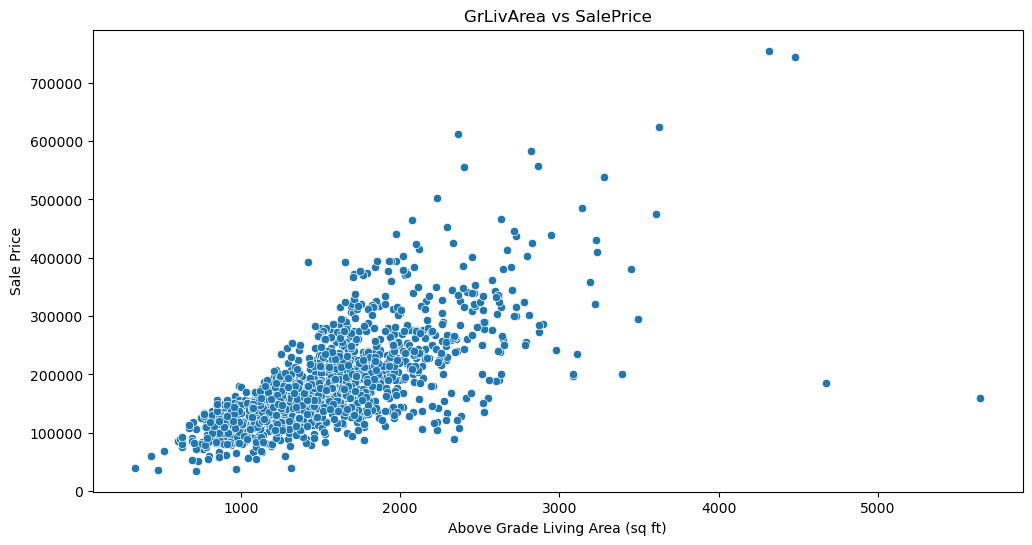

In [12]:
# Your code here - continuous numeric predictor

df = ames_clean

plt.figure(figsize=(12,6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('GrLivArea vs SalePrice')
plt.xlabel('Above Grade Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

### Discrete Numeric Predictor

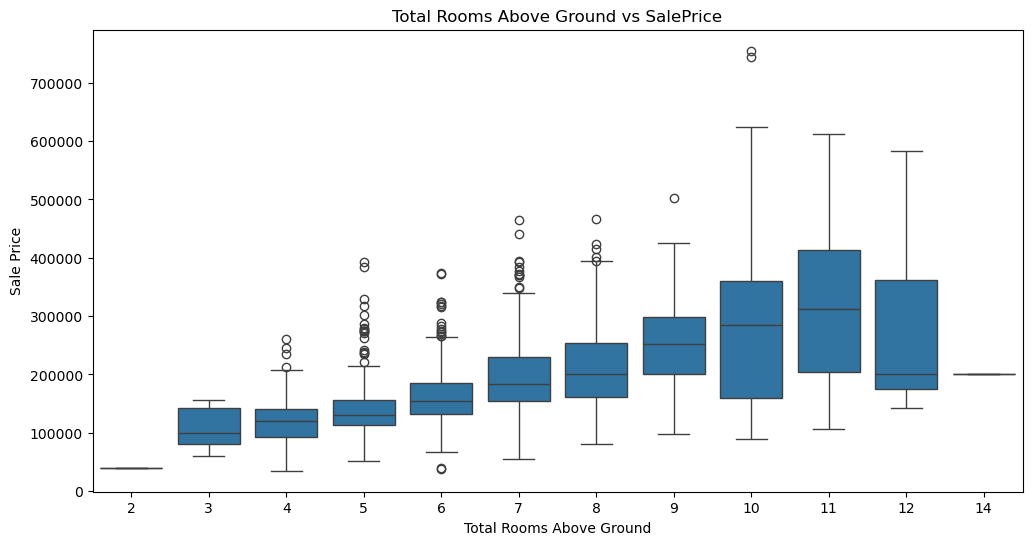

In [14]:
# Your code here - discrete numeric predictor

plt.figure(figsize=(12,6))
sns.boxplot(x='TotRmsAbvGrd', y='SalePrice', data=df)
plt.title('Total Rooms Above Ground vs SalePrice')
plt.xlabel('Total Rooms Above Ground')
plt.ylabel('Sale Price')
plt.show()

### String Categorical Predictor

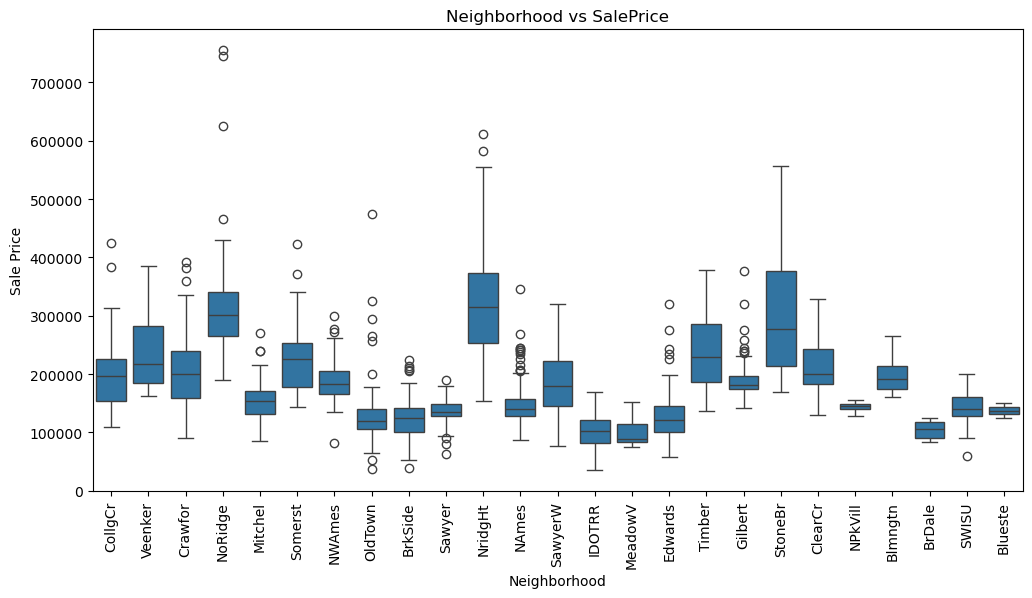

In [16]:
# Your code here - string categorical predictor

plt.figure(figsize=(12,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title('Neighborhood vs SalePrice')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price')
plt.show()

### Discrete Categorical Predictor

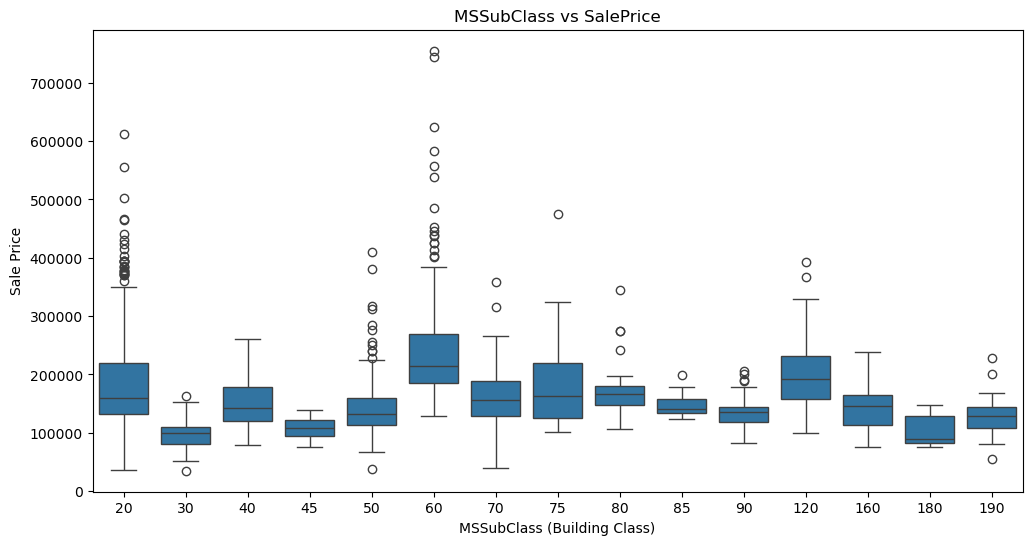

In [18]:
# Your code here - discrete categorical predictor

plt.figure(figsize=(12,6))
sns.boxplot(x='MSSubClass', y='SalePrice', data=df)
plt.title('MSSubClass vs SalePrice')
plt.xlabel('MSSubClass (Building Class)')
plt.ylabel('Sale Price')
plt.show()

## Step 3: Build a Multiple Regression Model with Your Chosen Predictors

Choose the best-looking 3 out of 4 predictors to include in your model.

Make sure that you one-hot encode your categorical predictor(s) (regardless of whether the current data type is a string or number) first.

In [20]:
# Your code here - prepare X and y, including one-hot encoding

# Select predictors and target variable 2 numeric + 1 categorical
predictors = ['GrLivArea', 'OverallQual', 'Neighborhood']
X = df[predictors]
y = df['SalePrice']

# One-hot encode the categorical predictor 'Neighborhood'
X_encoded = pd.get_dummies(X, columns=['Neighborhood'], drop_first=True)

In [21]:
# Your answer here - which category or categories were dropped?

print(sorted(df['Neighborhood'].unique()))

['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker']


In [22]:
# One-hot encoding the 'Neighborhood' column 
df_encoded = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

# Checking the new column names after encoding
print(df_encoded.columns)

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'GarageCars', 'GarageArea', 'PavedDrive', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice',
       'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide',
       'Neighborhood_C

In [23]:
print([col for col in df.columns if 'Neighborhood' in col])

['Neighborhood']


In [24]:
# Check the correlation matrix
print(X_encoded.corr())


                      GrLivArea  OverallQual  Neighborhood_Blueste  \
GrLivArea              1.000000     0.593007             -0.008670   
OverallQual            0.593007     1.000000             -0.002661   
Neighborhood_Blueste  -0.008670    -0.002661              1.000000   
Neighborhood_BrDale   -0.074599    -0.031355             -0.003899   
Neighborhood_BrkSide  -0.120958    -0.154120             -0.007533   
Neighborhood_ClearCr   0.072576    -0.020882             -0.005179   
Neighborhood_CollgCr  -0.022523     0.132337             -0.012533   
Neighborhood_Crawfor   0.100013     0.024109             -0.007046   
Neighborhood_Edwards  -0.090555    -0.199925             -0.010043   
Neighborhood_Gilbert   0.057302     0.079173             -0.008858   
Neighborhood_IDOTRR   -0.114550    -0.156588             -0.005972   
Neighborhood_MeadowV  -0.094329    -0.127870             -0.004020   
Neighborhood_Mitchel  -0.078493    -0.068404             -0.006902   
Neighborhood_NAmes  

In [25]:
# Your code here - build a regression model and display result

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Defining target and features
X = X_encoded
y = y  #  y = df['SalePrice']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Intercept:", model.intercept_)
print("R² Score:", model.score(X_test, y_test))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("\nTop 10 Feature Coefficients:")
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff_df.sort_values(by="Coefficient", ascending=False).head(10))

Intercept: -33918.088781314145
R² Score: 0.8062757239759908
RMSE: 38547.741715375625

Top 10 Feature Coefficients:
                       Coefficient
Neighborhood_NridgHt  71578.438701
Neighborhood_StoneBr  70712.542841
Neighborhood_NoRidge  62824.683470
Neighborhood_Veenker  55663.609212
Neighborhood_ClearCr  35774.893500
Neighborhood_Timber   32001.111669
Neighborhood_Somerst  22669.984415
OverallQual           20517.165873
Neighborhood_CollgCr  16201.112013
Neighborhood_Crawfor  16157.421671


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Step 4: Create Partial Regression Plots for Features

For each feature of the regression above (including the dummy features), plot the partial regression.

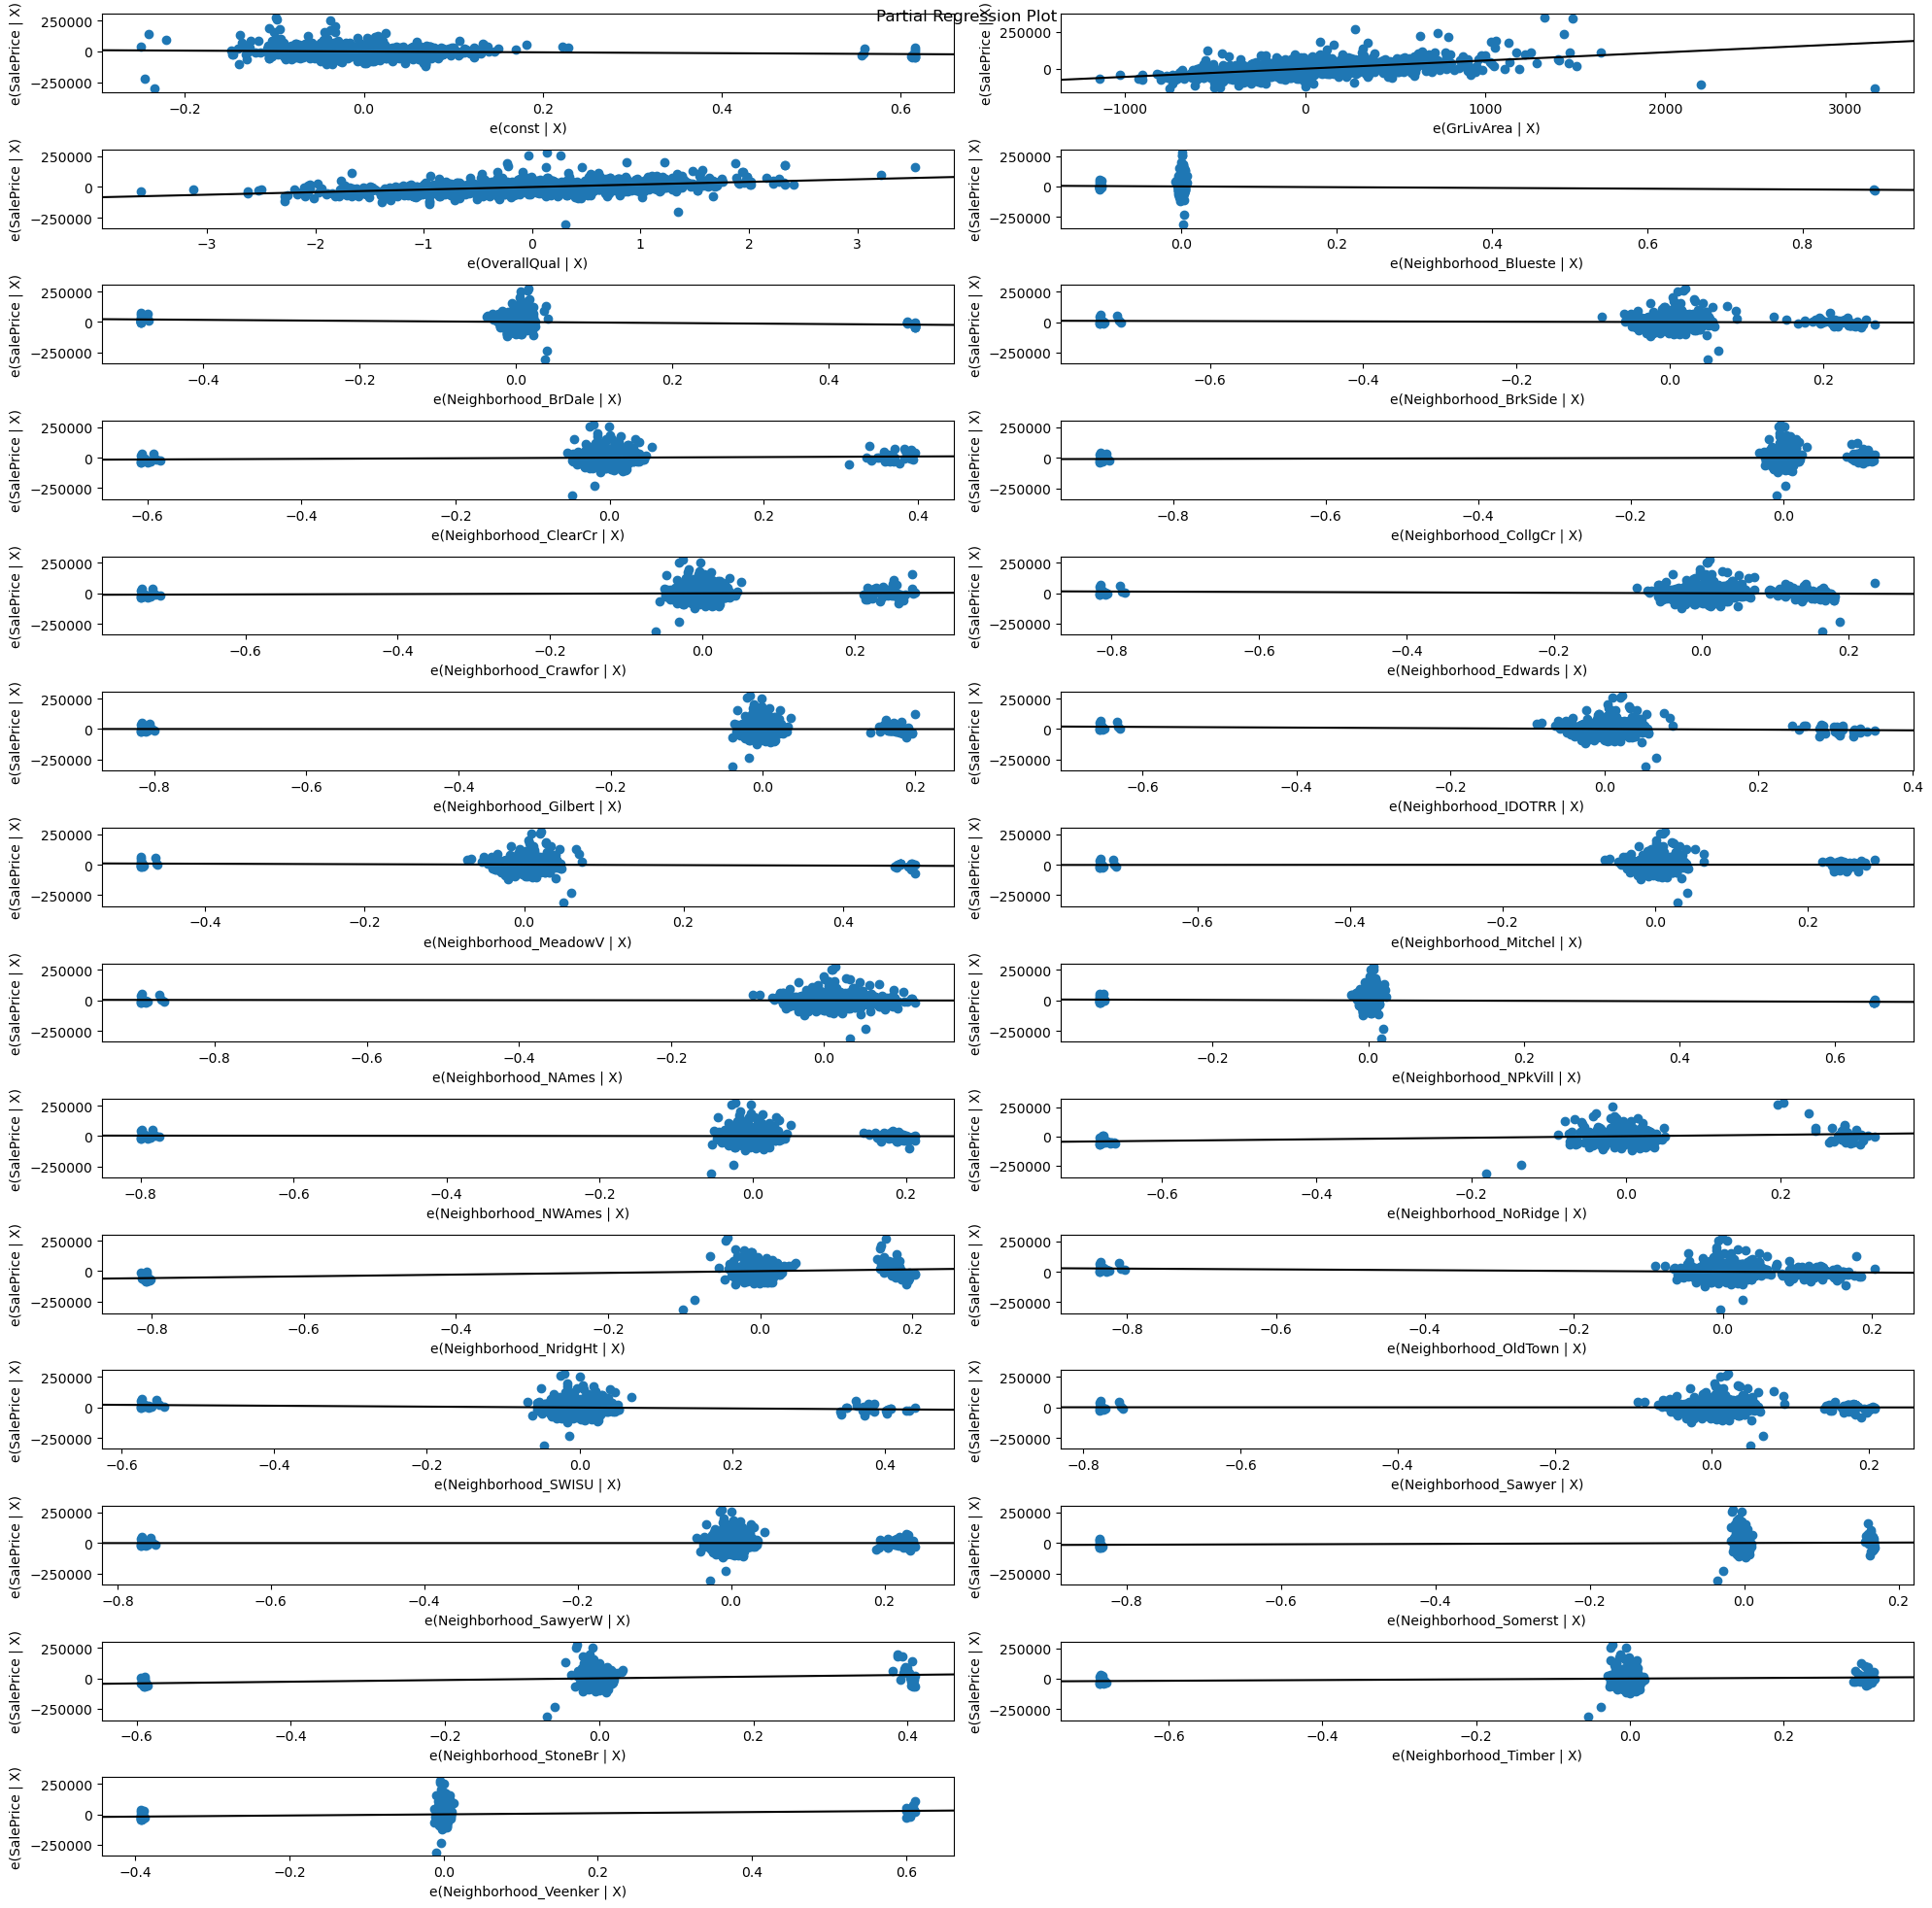

In [27]:
# Your code here - create partial regression plots

# Converting bools to int
X_encoded = X_encoded.astype(int)

# Adding a constant
X_sm = sm.add_constant(X_encoded)

# Fitting the model
model_sm = sm.OLS(y, X_sm).fit()

# Plotting partial regression plots
fig = plt.figure(figsize=(20, 20))
sm.graphics.plot_partregress_grid(model_sm, fig=fig)
plt.tight_layout()
plt.show()

## Step 5: Calculate an Error-Based Metric

In addition to the adjusted R-Squared that we can see in the model summary, calculate either MAE or RMSE for this model.

In [29]:
# Your code here - calculate an error-based metric

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predicting using the fitted model
y_pred = model_sm.predict(X_sm)

# Calculating MAE
mae = mean_absolute_error(y, y_pred)

# Calculating RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 24223.14
Root Mean Squared Error (RMSE): 36664.72


## Step 6: Summarize Findings

Between the model results, partial regression plots, and error-based metric, what does this model tell you? What would your next steps be to improve the model?

### Your answer here

#### Model Interpretation:
- Adjusted R-squared indicates the proportion of variance in SalePrice explained by the model, accounting for the number of predictors. A high value would suggest the model fits well, though it's not the sole measure of quality.
- Partial regression plots help visualize the relationship between each predictor and SalePrice, controlling for other variables. Some neighborhoods show stronger influence than others, and GrLivArea and OverallQual appear to be strong predictors.
- MAE (\\$24,223) and RMSE (\\$36,665) - The relatively large RMSE suggests the model makes significant errors on some predictions, likely due to outliers or omitted variables.

#### Next Steps to Improve the Model:

1. Feature Engineering
- Adding more relevant features such as year built, garage area, or number of bathrooms. Also Considering interactions e.g. OverallQual * GrLivArea), which may reveal deeper relationships.

2. Check for Multicollinearity
- Use of Variance Inflation Factor (VIF) to detect correlated features that might inflate variances.

3. Outlier Detection
- Investigate and possibly remove extreme outliers influencing the RMSE.

4. Polynomial Terms or Non-linear Models
- For non-linear, try adding polynomial terms or switching to tree-based models like Random Forests or Gradient Boosting.

5. Cross-Validation
- Using cross-validation to assess how well the model generalizes to unseen data.

6. Categorical Variable Grouping
- Combining neighborhoods with similar effects to reduce model complexity and improve interpretability.

## Level Up (Optional)

Try transforming X using scikit-learn _and_ fitting a scikit-learn linear regression as well. If there are any differences in the result, investigate them.

In [33]:
# Your code here

from sklearn.linear_model import LinearRegression

# Fitting Linear Regression using Scikit-learn
linreg = LinearRegression()
linreg.fit(X_encoded, y)

# Predict
y_pred = linreg.predict(X_encoded)

# Evaluating
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Scikit-learn MAE: {mae:.2f}")
print(f"Scikit-learn RMSE: {rmse:.2f}")

# Results
print(f"Statsmodels R²: {model_sm.rsquared:.4f}")
print(f"Statsmodels Adj. R²: {model_sm.rsquared_adj:.4f}")

Scikit-learn MAE: 24223.14
Scikit-learn RMSE: 36664.72
Statsmodels R²: 0.7868
Statsmodels Adj. R²: 0.7830


#### Model Performance
- R² = 0.7868 means the model explains 79% of the variance in sale prices.
- Adjusted R² = 0.7830 accounts for the number of predictors, showing added features are mostly meaningful.
- MAE = \\$24,223 and RMSE = \\$36,665 are reasonable error margins, but RMSE suggests some large errors or outliers.

## Summary

In this lab, you practiced your knowledge of categorical variables on the Ames Housing dataset! Specifically, you practiced distinguishing numeric and categorical data. You then created dummy variables using one hot encoding in order to build a multiple regression model.